## Week9 - Reinforcement Learning With Policy Gradient Method (REINFORCE)

This notebook serves as part of the **Computer Intelligence and its Applications in Mechatronics** course at **Amirkabir University of Technology**. The goal of this notebook is to implement the REINFORCE algorithm, a policy gradient method for reinforcement learning. The REINFORCE algorithm is used to train an agent to learn a policy that maximizes the expected cumulative reward in an environment.

In [3]:
import numpy as np
import gymnasium as gym
import tensorflow as tf
from tensorflow.keras import layers
import random
from collections import deque
import matplotlib.pyplot as plt
import pandas as pd
from IPython import display
from IPython.display import clear_output

In [4]:
def plot_score_epsilon(episode_rewards, epsilons = None):
    clear_output(wait=True)
    plt.style.use('ggplot')
    plt.rc('font', size=10)
    window=50

    plt.figure(figsize=(8, 4))
    plt.title('Total Rewards')

    rolling_mean = pd.Series(episode_rewards).rolling(window).mean()
    std = pd.Series(episode_rewards).rolling(window).std()
    plt.plot(episode_rewards, label='Total Reward', linewidth=1)
    plt.plot(rolling_mean, label='Rolling Mean', linewidth=2)
    plt.fill_between(range(len(episode_rewards)), rolling_mean - std, rolling_mean + std, color='violet', alpha=0.6)

    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.legend()
    plt.grid('on')
    plt.show()

    if epsilons is not None:
        plt.figure(figsize=(8, 4))
        plt.title('Total Rewards')
        plt.plot(epsilons, linewidth=1)
        plt.xlabel("Episode")
        plt.ylabel("Epsilon")
        plt.title("Epsilon Decay Over Time")
        plt.grid('on')
        plt.show()


# Vanilla Policy Gradient - REINFORCE

In this notebook, we will implement the REINFORCE algorithm for CartPole environment. REINFORCE is a Monte Carlo policy gradient algorithm that updates the policy based on the returns of complete episodes. The algorithm uses the log probability of actions taken to compute the policy gradient. The algorithm of the REINFORCE method is given in the following steps:

1. **Initialize** the network parameter $\theta$ with random values.

2. **Generate $N$ trajectories**  
   $\tau_i = \{(s_t, a_t, r_t)\}_{t=1}^{T_i}, \quad i = 1, \dots, N$  
   following the policy $\pi_\theta$.

3. **Compute the return of each trajectory**  
   $R(\tau_i) = \sum_{t=1}^{T_i} r_t$

4. **Compute the policy gradient**  
   $$
   \nabla_\theta J(\theta) = \frac{1}{N} \sum_{i=1}^{N} \sum_{t=1}^{T_i} \nabla_\theta \log \pi_\theta(a_t^i | s_t^i) \, R(\tau_i)
   $$

5. **Update the network parameters**  
   $$
   \theta \leftarrow \theta + \alpha \nabla_\theta J(\theta)
   $$

6. **Repeat** steps 2–5 for several iterations.

In [ ]:
# Hyperparameters
learning_rate = 1e-3
gamma = 0.99
episodes = 3000
batch_size = 32

episode_rewards = []

In [9]:
# Create environment
env = gym.make("CartPole-v1", render_mode="human")
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

# Define the policy network (outputs action probabilities)
policy = tf.keras.Sequential([
    layers.Input(shape=(state_dim,)),
    layers.Dense(24, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(n_actions, activation='softmax')  # Probabilities for actions
])

optimizer = tf.keras.optimizers.Adam(learning_rate)

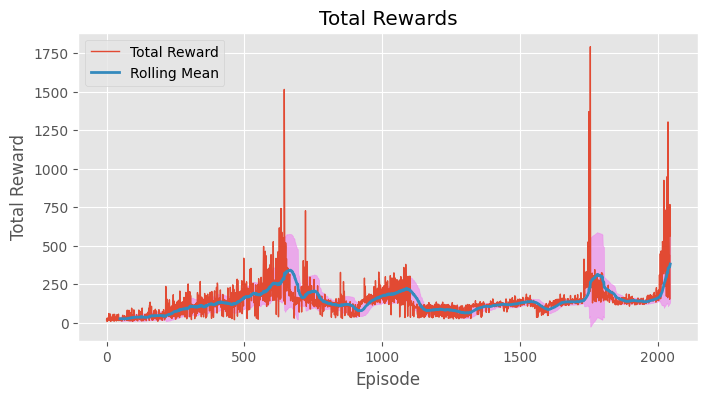

In [ ]:
# Training loop
for episode in range(episodes):
    states, actions, rewards = [], [], []
    total_reward = 0
    state, _ = env.reset()

    # Collect experience
    done = False
    while not done:
        state = np.array(state, dtype=np.float32).reshape(1, -1)  # Reshape to match input shape
        action_probs = policy(state).numpy()[0]
        action = np.random.choice(env.action_space.n, p=action_probs)  # Sample action based on the policy

        next_state, reward, done, truncated, _ = env.step(action)
        total_reward += reward
        # Store states, actions, and rewards
        states.append(state)
        actions.append(action)
        rewards.append(reward)

        state = next_state

    # Run training in batches
    returns = np.zeros_like(rewards, dtype=np.float32)
    running_return = 0
    for t in reversed(range(len(rewards))):
        running_return = rewards[t] + gamma * running_return
        returns[t] = running_return

    # Convert to numpy arrays    
    returns = np.array(returns, dtype=np.float32)
    states_batch = np.vstack(states)

    # Perform training
    with tf.GradientTape() as tape:
        # Calculate the probability of each action taken
        action_probs = policy(states_batch)
        action_indices = np.array(actions, dtype=np.int32)

        # Gather the probabilities for the actions taken
        action_log_probs = tf.math.log(tf.reduce_sum(action_probs * tf.one_hot(action_indices, env.action_space.n), axis=1))

        # Calculate the loss (negative log likelihood * returns)
        loss = -tf.reduce_mean(action_log_probs * returns)

    # Compute gradients and apply to update policy
    grads = tape.gradient(loss, policy.trainable_variables)
    optimizer.apply_gradients(zip(grads, policy.trainable_variables))

    # Clear memory after each batch
    states, actions, rewards = [], [], []

    episode_rewards.append(total_reward)
    plot_score_epsilon(episode_rewards)